In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
print("Loading MNIST dataset...")

mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target.astype(int)

print("Dataset Loaded Successfully!")
print("Features Shape:", X.shape)
print("Labels Shape:", y.shape)

Loading MNIST dataset...


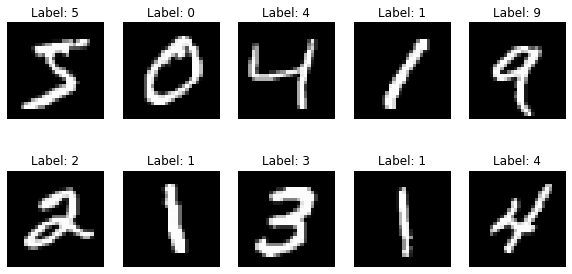

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10,5))

for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(28,28), cmap='gray')
    ax.set_title(f"Label: {y[i]}")
    ax.axis('off')

plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 56000
Testing Samples: 14000


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data Normalized Successfully")

Data Normalized Successfully


In [ ]:
perceptron = Perceptron(
    max_iter=1000,
    eta0=0.01,
    random_state=42
)

perceptron.fit(X_train, y_train)

print("Training Completed")

Training Completed


In [ ]:
y_pred = perceptron.predict(X_test)

print("Prediction Completed")

Prediction Completed


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 88.33 %


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1343
           1       0.93      0.95      0.94      1600
           2       0.85      0.89      0.87      1380
           3       0.86      0.85      0.85      1433
           4       0.89      0.91      0.90      1295
           5       0.84      0.85      0.84      1273
           6       0.93      0.93      0.93      1396
           7       0.87      0.90      0.89      1503
           8       0.83      0.79      0.81      1357
           9       0.87      0.81      0.84      1420

    accuracy                           0.88     14000
   macro avg       0.88      0.88      0.88     14000
weighted avg       0.88      0.88      0.88     14000



In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1275    2   13    3    3    7   26    4    9    1]
 [   0 1514   12   15    2   14    3    4   35    1]
 [   7   20 1224   12   22   12   23   10   39   11]
 [   6   15   59 1217    5   46    8   22   31   24]
 [   2    5    8   11 1173   10    8   14   14   50]
 [  15    6   12   61   17 1077   16    7   45   17]
 [  12    6   43    0   12   15 1297    2    6    3]
 [   7    8   37    5   26    9    1 1358    7   45]
 [  10   37   22   57    7   87   17   15 1077   28]
 [   6   10    3   37   50    7    0  125   28 1154]]


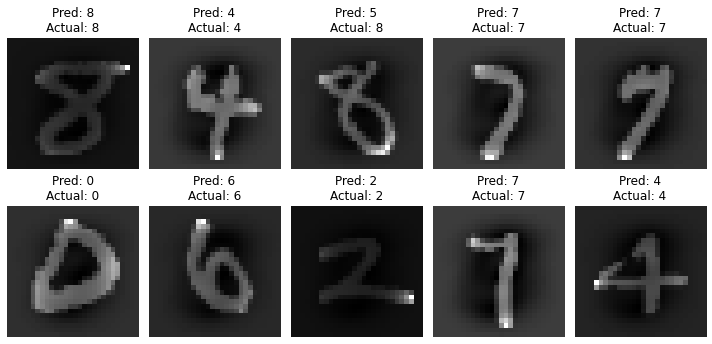

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10,5))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(28,28), cmap='gray')
    ax.set_title(
        f"Pred: {y_pred[i]}\nActual: {y_test[i]}"
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

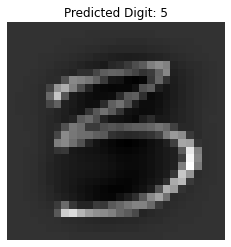

In [ ]:
index = 100

sample = X_test[index].reshape(1,-1)

prediction = perceptron.predict(sample)

plt.imshow(X_test[index].reshape(28,28), cmap='gray')
plt.title(f"Predicted Digit: {prediction[0]}")
plt.axis('off')
plt.show()

Loading MNIST Dataset...
Dataset Shape: (70000, 784)
Labels Shape: (70000,)

Training MLP...


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:614: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(



Accuracy: 97.52 %

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1343
           1       0.99      0.99      0.99      1600
           2       0.97      0.97      0.97      1380
           3       0.97      0.97      0.97      1433
           4       0.97      0.98      0.98      1295
           5       0.97      0.97      0.97      1273
           6       0.98      0.99      0.98      1396
           7       0.97      0.98      0.97      1503
           8       0.97      0.96      0.96      1357
           9       0.97      0.96      0.97      1420

    accuracy                           0.98     14000
   macro avg       0.98      0.98      0.98     14000
weighted avg       0.98      0.98      0.98     14000


Confusion Matrix:
[[1324    1    4    1    0    1    3    4    4    1]
 [   0 1581    3    5    1    0    2    6    2    0]
 [   2    8 1342    5    3    4    2    5    5    4]
 [   1    0    9 138

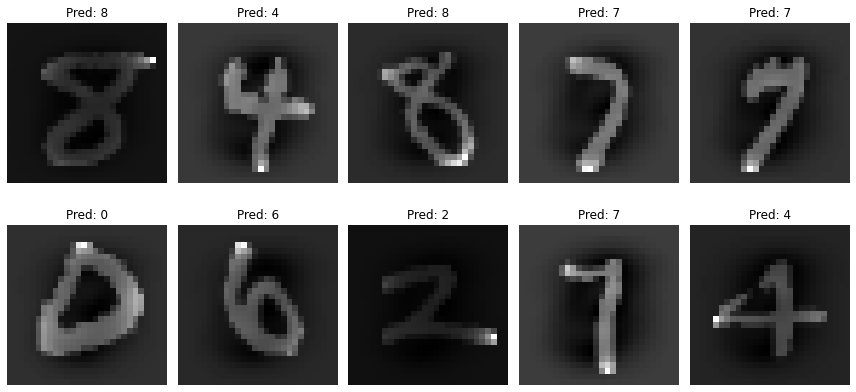

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load MNIST Dataset
print("Loading MNIST Dataset...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target.astype(int)

print("Dataset Shape:", X.shape)
print("Labels Shape:", y.shape)

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Normalize Features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create MLP Model
mlp = MLPClassifier(
    hidden_layer_sizes=(128,),  # One Hidden Layer
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=20,
    random_state=42
)

print("\nTraining MLP...")
mlp.fit(X_train, y_train)

# Prediction
y_pred = mlp.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", round(accuracy * 100, 2), "%")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Display Sample Predictions
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Pred: {y_pred[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

Loading MNIST Dataset...
Dataset Shape: (70000, 784)
Labels Shape: (70000,)

Training DNN...


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:614: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(



Accuracy: 97.34 %

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1343
           1       0.99      0.98      0.99      1600
           2       0.96      0.97      0.97      1380
           3       0.98      0.96      0.97      1433
           4       0.99      0.97      0.98      1295
           5       0.96      0.98      0.97      1273
           6       0.98      0.98      0.98      1396
           7       0.97      0.97      0.97      1503
           8       0.95      0.97      0.96      1357
           9       0.95      0.97      0.96      1420

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000


Confusion Matrix:
[[1323    0    3    1    0    3    6    2    4    1]
 [   0 1570    5    5    1    1    0    7    6    5]
 [   1    2 1337    4    1    3   10    3   17    2]
 [   0    0   13 137

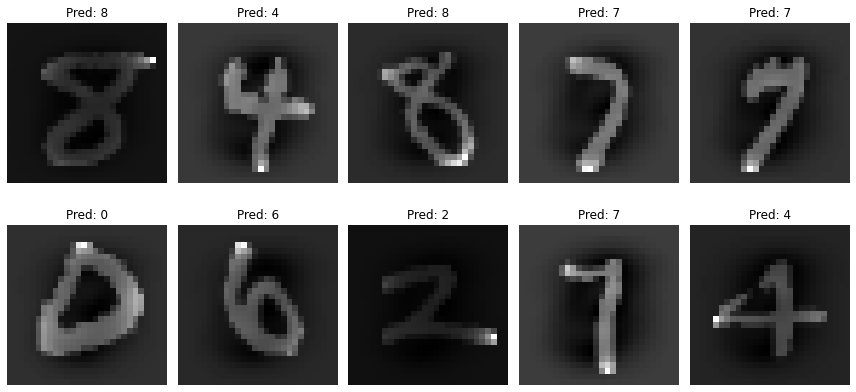

In [ ]:
   import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load MNIST Dataset
print("Loading MNIST Dataset...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target.astype(int)

print("Dataset Shape:", X.shape)
print("Labels Shape:", y.shape)

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Normalize Features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create Deep Neural Network
dnn = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),   # Multiple Hidden Layers
    activation='relu',
    solver='adam',
    batch_size=128,
    learning_rate_init=0.001,
    max_iter=30,
    random_state=42
)

print("\nTraining DNN...")
dnn.fit(X_train, y_train)

# Prediction
y_pred = dnn.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", round(accuracy * 100, 2), "%")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Display Sample Predictions
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Pred: {y_pred[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [2]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Load MNIST dataset
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target.astype(int)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Use a subset for faster tuning
X_train_small = X_train[:10000]
y_train_small = y_train[:10000]

# Create MLP model
mlp = MLPClassifier(max_iter=20, random_state=42)

# Hyperparameter grid
param_grid = {
    'hidden_layer_sizes': [(64,), (128,), (64,64)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01],
    'solver': ['adam']
}

# Grid Search
grid = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

# Train
grid.fit(X_train_small, y_train_small)

# Best parameters
print("Best Parameters:")
print(grid.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid.best_score_)

# Test
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("\nTest Accuracy:")
print(accuracy_score(y_test, y_pred))

Best Parameters:
{'activation': 'relu', 'hidden_layer_sizes': (128,), 'learning_rate_init': 0.001, 'solver': 'adam'}

Best Cross Validation Accuracy:
0.9012995480711838

Test Accuracy:
0.922


c:\Users\sumanth mannam\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


In [4]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# Load MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target.astype(int)

# Normalize data
X = X / 255.0

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (56000, 784)
X_test : (14000, 784)


In [5]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

mlp = MLPClassifier(
    hidden_layer_sizes=(128,),
    activation='relu',
    solver='adam',
    max_iter=20,
    random_state=42
)

mlp.fit(X_train, y_train)

y_pred_mlp = mlp.predict(X_test)

print("MLP Accuracy:", accuracy_score(y_test, y_pred_mlp))

MLP Accuracy: 0.9757857142857143


c:\Users\sumanth mannam\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


In [6]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

dnn = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    max_iter=20,
    random_state=42
)

dnn.fit(X_train, y_train)

y_pred_dnn = dnn.predict(X_test)

print("DNN Accuracy:", accuracy_score(y_test, y_pred_dnn))

DNN Accuracy: 0.9792857142857143


c:\Users\sumanth mannam\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


In [7]:
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Use a smaller subset for faster execution
X_train_small = X_train[:10000]
y_train_small = y_train[:10000]

param_grid = {
    'hidden_layer_sizes': [(64,), (128,), (64, 64)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01],
    'solver': ['adam']
}

grid = GridSearchCV(
    estimator=MLPClassifier(max_iter=20, random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train_small, y_train_small)

print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Accuracy:", grid.best_score_)

best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

print("Optimized Model Accuracy:", accuracy_score(y_test, y_pred_best))

Best Parameters: {'activation': 'relu', 'hidden_layer_sizes': (128,), 'learning_rate_init': 0.01, 'solver': 'adam'}
Best Cross Validation Accuracy: 0.9505003889711107
Optimized Model Accuracy: 0.9609285714285715


c:\Users\sumanth mannam\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
